# trust_model 분석

In [9]:
import pandas as pd
from pathlib import Path

# 원본 데이터 로드
filepath = "../../../../data/ML/preprocessed_office_data.csv"
df = pd.read_csv(filepath, encoding="utf-8-sig")

print(f"   행 수: {len(df):,}")
print(f"   열 수: {len(df.columns)}")
df.info()

   행 수: 356
   열 수: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   등록번호       356 non-null    object 
 1   중개사무소명     356 non-null    object 
 2   대표자        356 non-null    object 
 3   전화번호       356 non-null    object 
 4   주소         356 non-null    object 
 5   거래완료       356 non-null    object 
 6   등록매물       356 non-null    object 
 7   보증보험시작일    356 non-null    object 
 8   보증보험종료일    356 non-null    object 
 9   등록일        356 non-null    object 
 10  상태구분코드     356 non-null    float64
 11  상태구분명      356 non-null    object 
 12  지역코드       356 non-null    float64
 13  지역명        356 non-null    object 
 14  최종수정일      356 non-null    object 
 15  총_직원수      356 non-null    int64  
 16  공인중개사수     356 non-null    int64  
 17  중개보조원수     356 non-null    int64  
 18  대표수        356 non-null    int64  
 19  일반직원수      356 non-null    

In [10]:
def to_int(x):
    if isinstance(x, str):
        return int(x.replace("건", "").strip())
    return x

df["거래완료"] = df["거래완료_숫자"].apply(to_int)
df["등록매물"] = df["등록매물_숫자"].apply(to_int)

# 2. 전체 매물 (거래완료 + 등록매물)
df["전체매물"] = df["거래완료"] + df["등록매물"]

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 3. 거래성사율 계산 (0으로 나누기 방지)
df["거래성사율"] = df["거래완료"] / (df["전체매물"])

print(df[["거래완료", "등록매물", "전체매물", "거래성사율"]].head())

    거래완료  등록매물   전체매물     거래성사율
0  161.0  10.0  171.0  0.941520
1   76.0   5.0   81.0  0.938272
2  403.0  12.0  415.0  0.971084
3  152.0  12.0  164.0  0.926829
4  380.0  14.0  394.0  0.964467


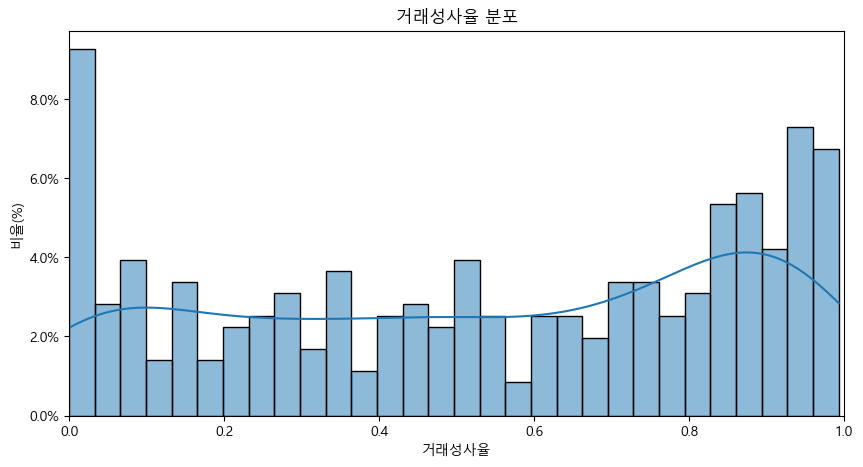

In [14]:
# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,5))
sns.histplot(df["거래성사율"], bins=30, kde=True, stat="probability")

plt.xlim(0, 1)
plt.xlabel("거래성사율")
plt.ylabel("비율(%)")
plt.title("거래성사율 분포")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

# 지역별 Z-score
- 지역별 거래 성사율의 평균, 표준편차를 계산

In [20]:
# 지역별 평균과 표준편차 계산
region_mean = df.groupby("지역명")["거래성사율"].transform("mean")
region_std  = df.groupby("지역명")["거래성사율"].transform("std")

# Z-score 생성  
df["Zscore"] = (df["거래성사율"] - region_mean) / (region_std)


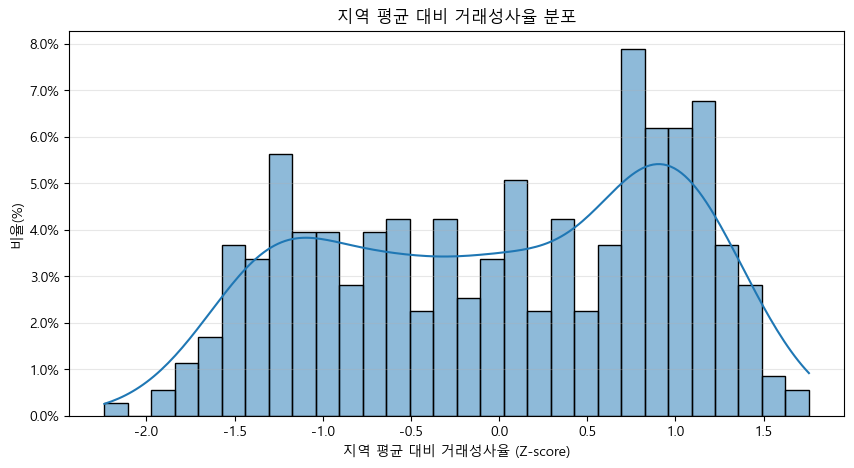

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))

sns.histplot(df["Zscore"], bins=30, kde=True, stat="probability")

plt.xlabel("지역 평균 대비 거래성사율 (Z-score)")
plt.ylabel("비율(%)")
plt.title("지역 평균 대비 거래성사율 분포")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)

plt.show()


#  개인성사율이 지역 평균보다 얼마나 높은지
# -------------------------------------
#  그 지역 성사율이 원래 얼마나 들쭉날쭉한가

In [22]:
# 분위수 경계 계산
q30 = df["Zscore"].quantile(0.30)
q70 = df["Zscore"].quantile(0.70)

print("분위수 기준값:")
print("  C 등급 최대:", q30)
print("  B 등급 최대:", q70)

# 등급화
def classify(z):
    if z <= q30:
        return "C"   # 하위
    elif z <= q70:
        return "B"   # 중간
    else:
        return "A"   # 상위

df["등급"] = df["Zscore"].apply(classify)


분위수 기준값:
  C 등급 최대: -0.6872812271662546
  B 등급 최대: 0.7582114793045392


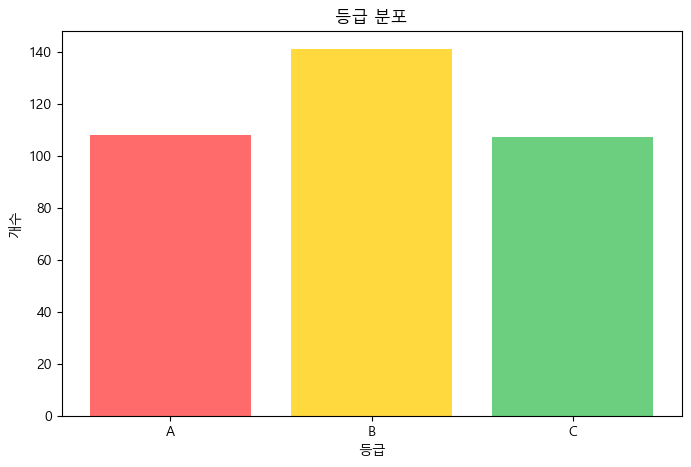

등급
A    108
B    141
C    107
Name: count, dtype: int64

비율:
등급
A    30.3
B    39.6
C    30.1
Name: count, dtype: float64%


In [23]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 등급 분포 계산
grade_counts = df["등급"].value_counts().sort_index()

# 막대 그래프
plt.figure(figsize=(8, 5))
plt.bar(grade_counts.index, grade_counts.values, 
        color=['#ff6b6b', '#ffd93d', '#6bcf7f'])
plt.title('등급 분포')
plt.xlabel('등급')
plt.ylabel('개수')
plt.show()

# 수치 출력
print(grade_counts)
print(f"\n비율:\n{(grade_counts / len(df) * 100).round(1)}%")